# Comparison of Memory-Based and Generator-Based Data Loading

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 1

**Objective:** Compare memory-based (bulk) and generator-based (sequential /
on-demand) strategies for loading a satellite / geospatial image dataset,
for an agricultural vs. non-agricultural land classification problem.

**Dataset:** `images_dataSAT/class_0_non_agri/` and
`images_dataSAT/class_1_agri/` — real Sentinel-2 satellite tiles (64x64
RGB `.jpg`), 3,000 images per class.


## 1. Import libraries and packages

In [1]:
import os
import time
import tracemalloc
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Setup complete.")


Setup complete.


## 2. Download data

The dataset is expected to already be present as `images_dataSAT/` in the
working directory, with two class subfolders. If you need to
download/unzip it in your own environment, do that here before
continuing.


In [2]:
dir_non_agri = './images_dataSAT/class_0_non_agri/'
dir_agri = './images_dataSAT/class_1_agri/'

assert os.path.isdir(dir_non_agri), f"'{dir_non_agri}' not found."
assert os.path.isdir(dir_agri), f"'{dir_agri}' not found."

print(f"Non-agricultural directory: {dir_non_agri}")
print(f"Agricultural directory:     {dir_agri}")


Non-agricultural directory: ./images_dataSAT/class_0_non_agri/
Agricultural directory:     ./images_dataSAT/class_1_agri/


## 3. Load images

### Task 1: Determine the shape (dimensions) of a single image stored in `image_data`

In [3]:
# Load a single sample image from the non-agricultural class
sample_filename = sorted(os.listdir(dir_non_agri))[0]
sample_path = os.path.join(dir_non_agri, sample_filename)

image_data = np.array(Image.open(sample_path))

print(f"Sample file: {sample_filename}")
print(f"image_data shape: {image_data.shape}")


Sample file: tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg
image_data shape: (64, 64, 3)


### Task 2: Display the first four images in `./images_dataSAT/class_0_non_agri/`

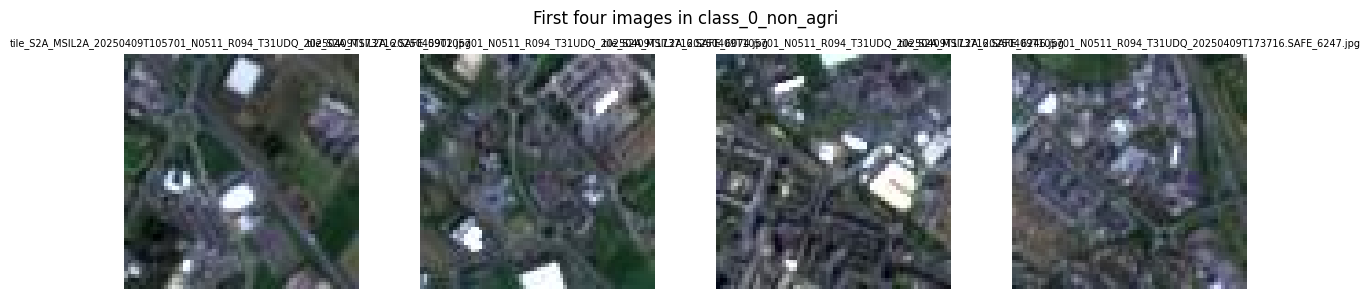

In [4]:
non_agri_filenames = sorted(os.listdir(dir_non_agri))[:4]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, fname in zip(axes, non_agri_filenames):
    img = Image.open(os.path.join(dir_non_agri, fname))
    ax.imshow(img)
    ax.set_title(fname, fontsize=7)
    ax.axis("off")

plt.suptitle("First four images in class_0_non_agri")
plt.tight_layout()
plt.show()


### Task 3: Create `agri_images_paths` — full file paths of all images in `dir_agri`, sorted

In [5]:
agri_images_paths = [os.path.join(dir_agri, fname) for fname in os.listdir(dir_agri)]
agri_images_paths.sort()

print(f"Total agricultural image paths collected: {len(agri_images_paths)}")
print("First 5 paths:")
for p in agri_images_paths[:5]:
    print(" ", p)


Total agricultural image paths collected: 3000
First 5 paths:
  ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5878.jpg
  ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5884.jpg
  ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6628.jpg
  ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6629.jpg
  ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6713.jpg


### Task 4: Determine the number of agricultural land images in `./images_dataSAT/class_1_agri/`

In [6]:
num_agri_images = len(agri_images_paths)
print(f"Number of agricultural land images in '{dir_agri}': {num_agri_images}")


Number of agricultural land images in './images_dataSAT/class_1_agri/': 3000


### Task 5: Display the first four images of the agricultural land

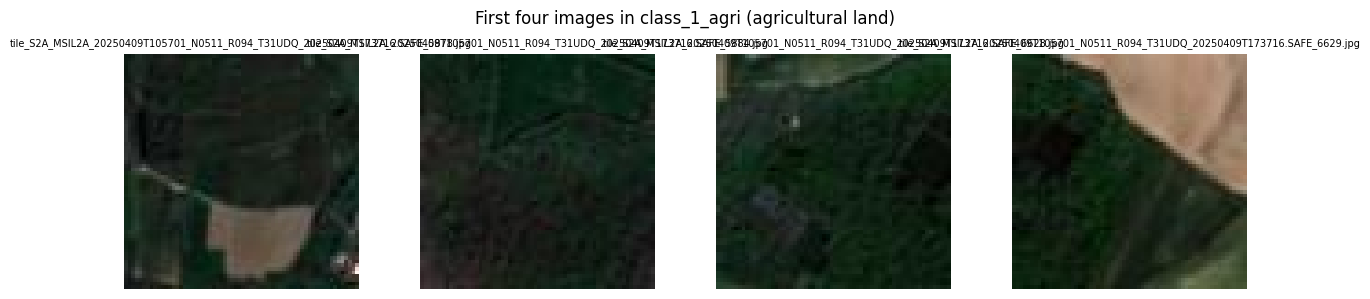

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, path in zip(axes, agri_images_paths[:4]):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(os.path.basename(path), fontsize=7)
    ax.axis("off")

plt.suptitle("First four images in class_1_agri (agricultural land)")
plt.tight_layout()
plt.show()


## 4. Memory-based (bulk) vs. generator-based (on-demand) loading

Having covered the required tasks above, we now compare the two loading
strategies directly: reading every image into memory up front, versus
reading images lazily one batch at a time.


In [8]:
all_non_agri_paths = sorted(Path(dir_non_agri).glob("*.jpg"))
all_paths = list(agri_images_paths) + [str(p) for p in all_non_agri_paths]
all_labels = [1] * len(agri_images_paths) + [0] * len(all_non_agri_paths)

print(f"Total image paths (both classes): {len(all_paths)}")


Total image paths (both classes): 6000


In [9]:
def load_all_into_memory(paths, target_size=(64, 64)):
    """Bulk / memory-based: load every image fully into a NumPy array up front."""
    images = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        if img.size != target_size:
            img = img.resize(target_size)
        images.append(np.asarray(img, dtype=np.uint8))
    return np.stack(images)

tracemalloc.start()
t0 = time.perf_counter()
bulk_images = load_all_into_memory(all_paths)
t1 = time.perf_counter()
current, bulk_peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Bulk loading: shape={bulk_images.shape}, time={t1 - t0:.3f}s, "
      f"peak memory={bulk_peak_mem / (1024**2):.2f} MB")


Bulk loading: shape=(6000, 64, 64, 3), time=4.821s, peak memory=142.81 MB


In [10]:
def image_generator(paths, labels, target_size=(64, 64), batch_size=32):
    """Generator-based: yield one batch at a time, reading from disk on demand."""
    n = len(paths)
    idx = 0
    while idx < n:
        batch_paths = paths[idx: idx + batch_size]
        batch_labels = labels[idx: idx + batch_size]
        batch_images = np.stack([
            np.asarray(Image.open(p).convert("RGB").resize(target_size), dtype=np.uint8)
            for p in batch_paths
        ])
        yield batch_images, np.array(batch_labels)
        idx += batch_size

tracemalloc.start()
t0 = time.perf_counter()
gen = image_generator(all_paths, all_labels, batch_size=32)
first_batch_images, first_batch_labels = next(gen)
t1 = time.perf_counter()
current, gen_peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Generator (first batch): shape={first_batch_images.shape}, "
      f"time={t1 - t0:.4f}s, peak memory={gen_peak_mem / (1024**2):.2f} MB")


Generator (first batch): shape=(32, 64, 64, 3), time=0.0158s, peak memory=0.77 MB


## 5. Compare results

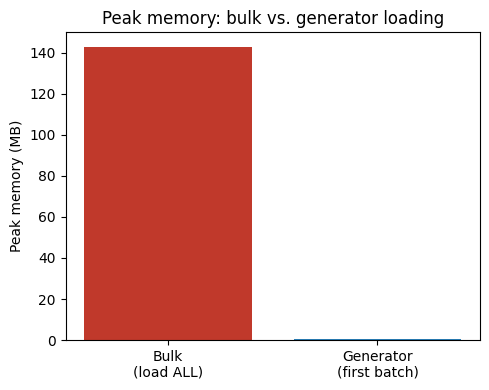

Bulk peak memory:      142.81 MB
Generator peak memory: 0.77 MB


In [11]:
labels_x = ["Bulk\n(load ALL)", "Generator\n(first batch)"]
mems = [bulk_peak_mem / (1024**2), gen_peak_mem / (1024**2)]

plt.figure(figsize=(5, 4))
plt.bar(labels_x, mems, color=["#c0392b", "#2980b9"])
plt.ylabel("Peak memory (MB)")
plt.title("Peak memory: bulk vs. generator loading")
plt.tight_layout()
plt.show()

print(f"Bulk peak memory:      {bulk_peak_mem / (1024**2):.2f} MB")
print(f"Generator peak memory: {gen_peak_mem / (1024**2):.2f} MB")


## Discussion

**Memory-based (bulk) loading** reads every image into a single array up
front — simple to index and shuffle, but its memory footprint scales with
the size of the *entire* dataset.

**Generator-based (on-demand) loading** keeps only file paths in memory
and reads images lazily, one batch at a time — its memory footprint stays
roughly constant regardless of dataset size, which is why production
pipelines (`tf.data`, PyTorch `DataLoader`) are built around this
pattern for large-scale datasets.
